replace UCI HAR Dataset/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset downloaded and extracted ✅
Data loaded successfully ✅
Labels mapped ✅
Data preprocessed ✅
Model trained ✅

Accuracy: 0.9260264675941635

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.91      0.89      0.90       491
           2       0.90      0.92      0.91       532
           3       0.89      0.96      0.92       496
           4       0.97      0.86      0.91       420
           5       0.89      0.90      0.90       471

    accuracy                           0.93      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.93      0.93      0.93      2947



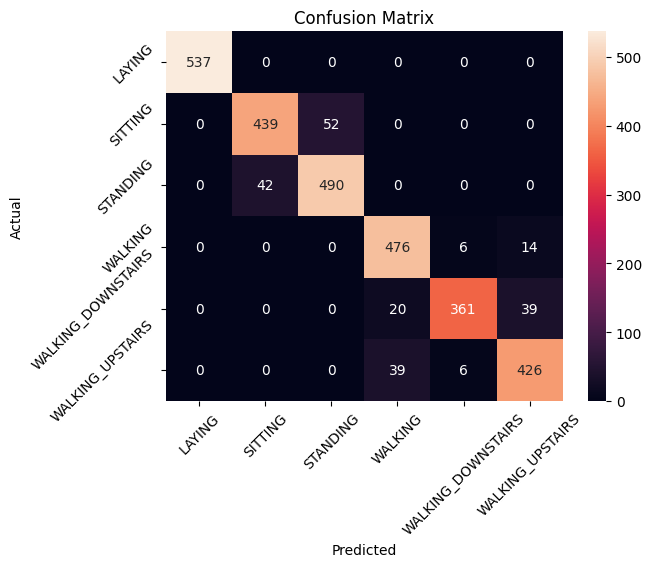

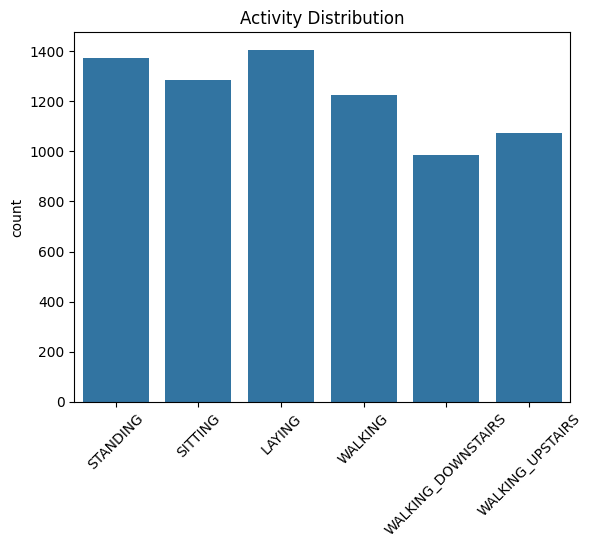


Sample Prediction:
Predicted: STANDING
Actual:  STANDING

🎉 Project Completed Successfully!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

# 2. Download Dataset
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip -q "UCI HAR Dataset.zip"

print("Dataset downloaded and extracted ✅")

# 3. Load Dataset
features = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None)
activity_labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None)

X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)

X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None)

print("Data loaded successfully ✅")

# 4. Assign Column Names
X_train.columns = features[1]
X_test.columns = features[1]

# 5. Map Activity Labels
activity_map = dict(zip(activity_labels[0], activity_labels[1]))

y_train[0] = y_train[0].map(activity_map)
y_test[0] = y_test[0].map(activity_map)

y_train = y_train[0]
y_test = y_test[0]

print("Labels mapped ✅")

# 6. Encode Labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# 7. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preprocessed ✅")

# 8. Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained ✅")

# 9. Prediction
y_pred = model.predict(X_test)

# 10. Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

# 12. Activity Distribution
plt.figure()
sns.countplot(x=le.inverse_transform(y_train))
plt.xticks(rotation=45)
plt.title("Activity Distribution")
plt.show()

# 13. Sample Prediction
sample = X_test[0].reshape(1, -1)
pred = model.predict(sample)

print("\nSample Prediction:")
print("Predicted:", le.inverse_transform(pred)[0])
print("Actual: ", le.inverse_transform([y_test[0]])[0])

print("\n🎉 Project Completed Successfully!")